# Project: Gaussian Naive Bayes From Scratch

**Overview:** Implement Gaussian Naive Bayes from scratch and compare with scikit-learn on a classic dataset.

**Task:** Multiclass classification
**Dataset:** Iris dataset (scikit-learn) or included in the notebook.


## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "class"]
iris = pd.read_csv(url, header=None, names=columns)
X = iris.drop("class", axis=1)
y = iris["class"]

print(iris.head())


   sepal_length  sepal_width  petal_length  petal_width        class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


## Naive Bayes

Classifier based on Bayes theorem .. naive assumption that features are conditionally independent given the class.

In our case, we have 4 features:

* Sepal Width
* Sepal Length
* Petal Width
* Petal Length

The features are continuos and the Output Target is a Class. Our data are of three types of irises.

Iris setosa,

Iris versicolor,

and Iris virginica

There are 50 examples for each Iris flower type. The total data is captured in 150x4 Matrix

## Bayes Theorem

For any class C (iris type) and feature vector X = ( x1, x2, x3, x4):

P(C | X) = (P (X | C) * P (C)) / P (X)


since P (X) is the same for all classes we will compare numerator only.

P(C | X) => (P (X | C) * P (C))

## Naive Independance Assumption

To simplify the computation. We assume that all the features are not correlated. That way we dont have to calculate the full joint probability distribution of the features.

So, for simplicity we will MULTIPLY all the individual probabilities for features given a class.

## Data Exploration (Understanding the Dataset)

Dataset Shape

In [3]:
print(X.shape)
print(y.shape)

(150, 4)
(150,)


150 samples, each sample with 4 features


In [4]:
# print(X)
# print(y)
np.unique(y)

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

Check for missing values

In [5]:
pd.isnull(X).sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0


There are no missing values. The iris dataset is clean, balanced and numeric so very little preprocessing is required.

In [6]:
print(np.mean(X, axis=0))
print(np.std(X, axis=0))

sepal_length    5.843333
sepal_width     3.054000
petal_length    3.758667
petal_width     1.198667
dtype: float64
sepal_length    0.825301
sepal_width     0.432147
petal_length    1.758529
petal_width     0.760613
dtype: float64


Values are continuous and reasonably spread. No extreme scale differences. This supports using Gaussian Naive Bayes.

### Vizualizations
Lets do some visualizations which are useful for understanding how naive bayes will work for iris dataset

Let plot the feature distributions for each class (Gaussian Assumption)

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
sepal_length
sepal_width
petal_length
petal_width


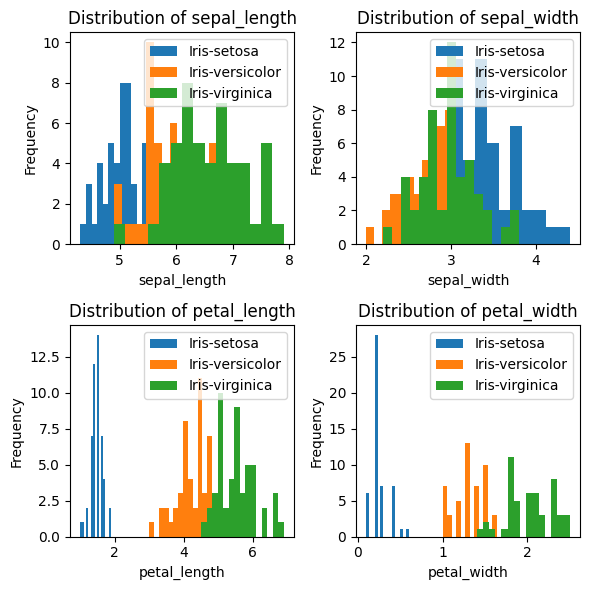

In [7]:
print(np.unique(y))
fig, axs = plt.subplots(2,2, figsize = (6,6))
axs = axs.flatten()

for ax, feature in zip(axs, X.columns):
  # plt.figure(figsize=(2, 2))
  print(feature)
  for iris_type in np.unique(y):
    # print(X.loc[y == iris_type, feature])
    ax.hist(
        X.loc[y == iris_type, feature],
        bins = 15,
        alpha= 1,
        label= iris_type
    )
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.show()

We plot histograms of each feature and class. We visually verified the gaussian assumption of Naive Bayes. The plots show the actual distributions with differences in means and variances that will be used to compute likelihoods. Lets plot these distributions as Curves using the mean and variance of each class.

First we will define the gaussian pdf function

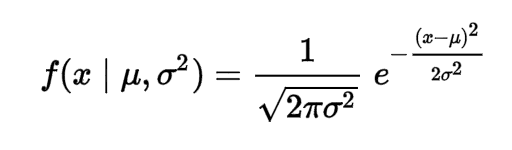

In [8]:
def gaussian_pdf(x, mean, std):
  return (1 / (np.sqrt(2 * np.pi) * std)) * np.exp(- ((x - mean) ** 2) / (2 * std ** 2))

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


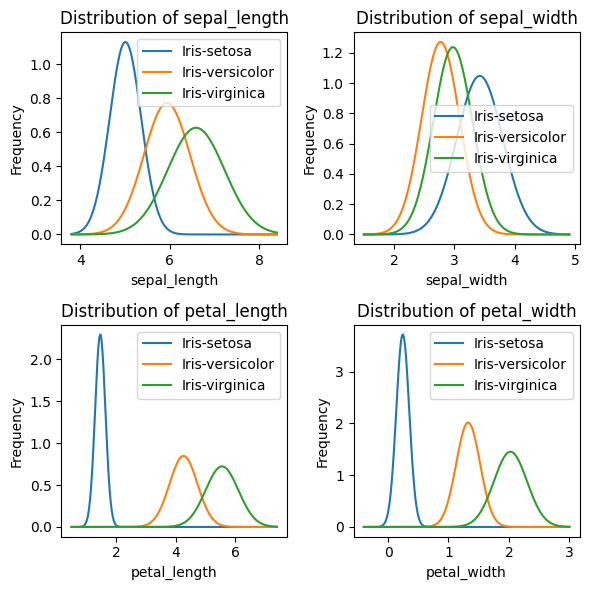

In [9]:
print(np.unique(y))
fig, axs = plt.subplots(2,2, figsize = (6,6))
axs = axs.flatten()

for ax, feature in zip(axs, X.columns):
  # plt.figure(figsize=(2, 2))
  # print(feature)

  x_min = X.loc[:, feature].min() - 0.5
  x_max = X.loc[:, feature].max() + 0.5
  x_values = np.linspace(x_min, x_max, 200)

  for iris_type in np.unique(y):
    # print(X.loc[y == iris_type, feature])
    mean_c = X.loc[y == iris_type, feature].mean()
    std_c = X.loc[y == iris_type, feature].std()

    ax.plot(x_values, gaussian_pdf(x_values, mean_c, std_c), label= iris_type)
    # ax.hist(
    #     X.loc[y == iris_type, feature],
    #     bins = 15,
    #     density = True,
    #     alpha= 1,
    #     label= iris_type
    # )
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.show()

Gaussian curves represent the probability of a feature value given a class. Peak of the curve is mean of the feature for that class. Width of the curve is standard deviation (variablity within a class).

* Sepal Length:
There is moderate overlap and the peaks are relatively close.
* Sepal Width:
Large overlap and peaks are very close to each other.
* Petal Length:
Less overlap and the peaks are well separated.
* Petal Width:
Less overlap and peaks are well separated.

For Naive Bayes:
The far apart curves (Petal Width and Petal Length) will give give better classification. For the wider overlapping curves (Sepal Width and Sepal Length), there is a higher chance of missclassification.

Naive Bayes combines all features and can still compensate using multiple features by product of likelihoods.

## Building the Model from Scratch

### Split the dataset into training and testing

In [10]:
def train_test_split(X, y, test_size=0.2, random_seed=42):
  np.random.seed(random_seed)
  indices = np.arange(X.shape[0]) #all row indices
  # print(indices)
  np.random.shuffle(indices) #shuffle randomly
  # print(indices)
  split_index = int(X.shape[0] * (1 - test_size)) #find the index to divide 80% train, 20% test
  # print(split_index)
  train_index, test_index = indices[:split_index], indices[split_index:]
  # print(train_index)
  # print(X.loc[train_index,:])
  return X.loc[train_index,:], X.loc[test_index,:], y.loc[train_index], y.loc[test_index]

X_train, X_test, y_train, y_test = train_test_split(X, y)

###Lets begin by calculating the class probabilities prior P(C)

In [11]:
def prob_by_class(X, y):
  classes = np.unique(y)
  priors = {}
  for cls in classes:
    #check for all samples which belong to the same class
    X_cls = X[y == cls]
    #calculate the probability
    priors[cls] = X_cls.shape[0] / X.shape[0]
  return priors

priors_iris_types = prob_by_class(X_train, y_train)
print(priors_iris_types)


{'Iris-setosa': 0.35833333333333334, 'Iris-versicolor': 0.325, 'Iris-virginica': 0.31666666666666665}


This makes sense because Iris dataset is balanced

###Predict for a single sample

Next, we will define the gaussian probability density function.  However, we need to calculate the mean and standard deviation before.

In [12]:
def mean_and_std(X, y):
  classes = np.unique(y)
  mean_and_std = {}
  for cls in classes:
    X_cls = X[y == cls]
    mean = X_cls.mean(axis=0)
    std = X_cls.std(axis=0)
    mean_and_std[cls] = {"mean": mean, "std": std}
  return mean_and_std

mean_and_std_iris = mean_and_std(X_train, y_train)
# print(mean_and_std_iris)

We defined the gaussian probability density function in the vizualizations part. Next I will make a function to predict the class of a single sample.

In [16]:
def predict_single_sample(priors, mean_std, x):
  probabilities = {}
  for cls in mean_std:
    probabilities[cls] = priors[cls]
    for i in range(len(x)):
      probabilities[cls] *= gaussian_pdf(x[i],mean_std[cls]['mean'][i],mean_std[cls]['std'][i])
  return max(probabilities, key=probabilities.get) #return the key with highest probability

In [17]:
#test a sample
print(predict_single_sample(priors_iris_types, mean_and_std_iris, [4.9, 3.0, 1.4, 0.2]))

Iris-setosa


/tmp/ipython-input-1673153540.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  probabilities[cls] *= gaussian_pdf(x[i],mean_std[cls]['mean'][i],mean_std[cls]['std'][i])


###Predict on the Test dataset

In [18]:
def predict(priors, mean_std, X):
  X = X.to_numpy()
  return np.array([predict_single_sample(priors, mean_std, x) for x in X])

In [19]:
y_pred = predict(priors_iris_types, mean_and_std_iris, X_test)

/tmp/ipython-input-1673153540.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  probabilities[cls] *= gaussian_pdf(x[i],mean_std[cls]['mean'][i],mean_std[cls]['std'][i])


In [20]:
accuracy = np.mean(y_test == y_pred) * 100
print(accuracy)

93.33333333333333


## Building the Model using Scikit-learn

In [21]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [22]:
y_pred_sklearn = model.predict(X_test)

In [23]:
print("Accuracy for scikit-learn model:", accuracy_score(y_test, y_pred_sklearn))
print("Accuracy for model built from scratch:", accuracy_score(y_test, y_pred_sklearn))

Accuracy for scikit-learn model: 0.9333333333333333
Accuracy for model built from scratch: 0.9333333333333333


In [24]:
print("Confusion Matrix for scikit-learn model: \n", confusion_matrix(y_test, y_pred_sklearn))
print("Confusion Matrix for model built from scratch: \n", confusion_matrix(y_test, y_pred))

Confusion Matrix for scikit-learn model: 
 [[ 7  0  0]
 [ 0 10  1]
 [ 0  1 11]]
Confusion Matrix for model built from scratch: 
 [[ 7  0  0]
 [ 0 10  1]
 [ 0  1 11]]


In [25]:
print("Classification Report for scikit-learn model: \n", classification_report(y_test, y_pred_sklearn))
print("Classification Report for model built from scratch: \n", classification_report(y_test, y_pred))

Classification Report for scikit-learn model: 
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         7
Iris-versicolor       0.91      0.91      0.91        11
 Iris-virginica       0.92      0.92      0.92        12

       accuracy                           0.93        30
      macro avg       0.94      0.94      0.94        30
   weighted avg       0.93      0.93      0.93        30

Classification Report for model built from scratch: 
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         7
Iris-versicolor       0.91      0.91      0.91        11
 Iris-virginica       0.92      0.92      0.92        12

       accuracy                           0.93        30
      macro avg       0.94      0.94      0.94        30
   weighted avg       0.93      0.93      0.93        30



## Conclusion

The model we built from scratch is correct and has exact match with scikit-learn built in model predictions. The overall accuracy is 93% which is high for a small dataset. Gaussian Naive Bayes is proven effective on Iris Dataset. Even with no conditional independence in real life, it handles separation well. For both implementations, Setosa class is perfectly classified. Very few errors occur only between Versicolor and Verginica due to overlap between classes.